# CARD: Whitened DDRM-Style Diffusion Restoration

This Colab notebook implements the CARD paper's denoising path  

The target problem is the paper's correlated-noise measurement model:

```text
y = H x0 + n,        n ~ N(0, sigma_y^2 Sigma)
```

For denoising, `H = I`. CARD first whitens the measurement equation:

```text
y_tilde = W y,       H_tilde = W H,       W Sigma W^T = I
```

Then restoration is performed with a pretrained diffusion prior while applying measurement consistency in the spectral basis of `H_tilde`. This notebook follows that structure for denoising with non-overlapping 8x8 patches, matching the paper's practical patchwise whitening setup.

Practical scope: this is still a course-sized Colab implementation. It uses OpenAI's public 64x64 guided-diffusion checkpoint for runtime reasons, while the paper reports full benchmark results at larger scale with DDRM code, ImageNet/LSUN/CIN-D, LPIPS, deblurring, and super-resolution.
        


##  Setup
the pretrained model is the public OpenAI 64x64 ImageNet guided-diffusion model.
        


In [45]:
# Colab setup. Run this cell in Google Colab, not locally.
!git clone -q https://github.com/openai/guided-diffusion.git /content/guided-diffusion || true
!pip -q install blobfile matplotlib pillow tqdm

import sys
from pathlib import Path

sys.path.append("/content/guided-diffusion")
Path("/content/models").mkdir(parents=True, exist_ok=True)

MODEL_URL = "https://openaipublic.blob.core.windows.net/diffusion/jul-2021/64x64_diffusion.pt"
MODEL_PATH = "/content/models/64x64_diffusion.pt"
!wget -nc {MODEL_URL} -O {MODEL_PATH}


fatal: destination path '/content/guided-diffusion' already exists and is not an empty directory.
File ‘/content/models/64x64_diffusion.pt’ already there; not retrieving.


## imports


In [46]:
import math
from dataclasses import dataclass
from typing import Final

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import torch
import torch.nn.functional as torch_functional
from guided_diffusion.script_util import create_model_and_diffusion, model_and_diffusion_defaults
from PIL import Image

FloatArray = npt.NDArray[np.float32]

DEVICE: Final = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)


device: cuda


## Load Frozen Diffusion Prior

CARD is training-free: the diffusion model is frozen and used only as a pretrained natural-image prior. The paper uses DDRM-compatible pretrained backbones and 20 neural function evaluations in its reported setup. Here `timestep_respacing="20"` follows that 20-step sampling budget.
        


In [47]:
def load_guided_diffusion_64(device: torch.device) -> tuple[torch.nn.Module, object]:
    options = model_and_diffusion_defaults()
    options.update(
        {
            "attention_resolutions": "32,16,8",
            "class_cond": True,
            "diffusion_steps": 1000,
            "dropout": 0.1,
            "image_size": 64,
            "learn_sigma": True,
            "noise_schedule": "cosine",
            "num_channels": 192,
            "num_head_channels": 64,
            "num_res_blocks": 3,
            "resblock_updown": True,
            "timestep_respacing": "50",
            "use_fp16": False,
            "use_new_attention_order": True,
            "use_scale_shift_norm": True,
        }
    )
    model, diffusion = create_model_and_diffusion(**options)
    state = torch.load("/content/models/64x64_diffusion.pt", map_location="cpu")
    model.load_state_dict(state)
    model.to(device).eval()
    return model, diffusion


DIFFUSION_MODEL, DIFFUSION = load_guided_diffusion_64(DEVICE)
print("frozen diffusion prior loaded")



frozen diffusion prior loaded


## Test Images and Correlated Measurements

The paper evaluates CARD across datasets and scenes rather than a single image. in this implementation Each image is corrupted by the same correlated sensor-noise model so the metric charts compare restoration behavior across inputs.


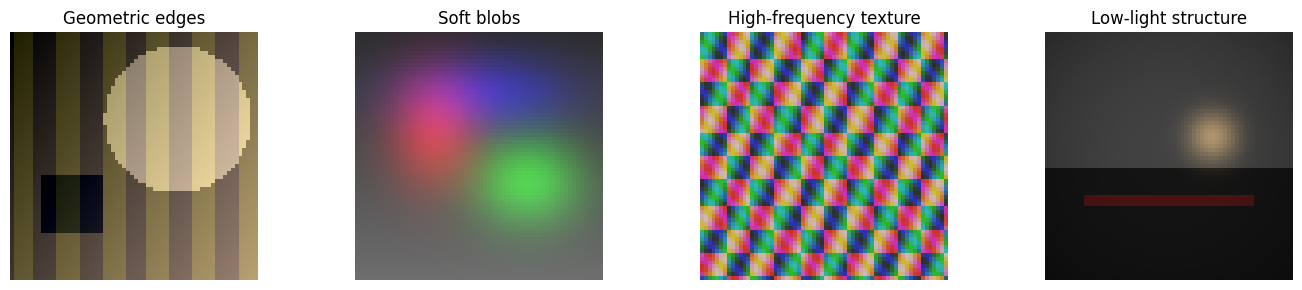

In [48]:
IMAGE_SIZE: Final = 64
DISK_RADIUS_SQUARED: Final = 0.09
SQUARE_X_MIN: Final = 0.12
SQUARE_X_MAX: Final = 0.38
SQUARE_Y_MIN: Final = 0.58
SQUARE_Y_MAX: Final = 0.82

LOW_LIGHT_HORIZON_Y: Final = 0.55
LOW_LIGHT_LINE_Y: Final = 0.68
LOW_LIGHT_LINE_HALF_WIDTH: Final = 0.02
LOW_LIGHT_LINE_X_MIN: Final = 0.15
LOW_LIGHT_LINE_X_MAX: Final = 0.85


@dataclass(frozen=True)
class TestImage:
    name: str
    clean: FloatArray


def coordinate_grid(size: int = IMAGE_SIZE) -> tuple[FloatArray, FloatArray]:
    coords = np.linspace(0.0, 1.0, size, dtype=np.float32)
    return np.meshgrid(coords, coords)


def make_geometric_scene(size: int = IMAGE_SIZE) -> FloatArray:
    x_grid, y_grid = coordinate_grid(size)
    base = 0.35 * x_grid + 0.25 * y_grid
    disk = ((x_grid - 0.68) ** 2 + (y_grid - 0.35) ** 2) < DISK_RADIUS_SQUARED
    square = (
        (x_grid > SQUARE_X_MIN)
        & (x_grid < SQUARE_X_MAX)
        & (y_grid > SQUARE_Y_MIN)
        & (y_grid < SQUARE_Y_MAX)
    )
    stripes = 0.12 * (np.sin(34 * x_grid) > 0)
    image = np.stack([base + stripes, base * 0.85 + stripes, base * 0.75], axis=-1)
    image[disk, :] += np.array([0.35, 0.33, 0.28], dtype=np.float32)
    image[square, :] -= np.array([0.25, 0.20, 0.12], dtype=np.float32)
    return np.clip(image, 0.0, 1.0).astype(np.float32)


def make_soft_blobs_scene(size: int = IMAGE_SIZE) -> FloatArray:
    x_grid, y_grid = coordinate_grid(size)
    red_blob = np.exp(-(((x_grid - 0.32) ** 2) / 0.035 + ((y_grid - 0.38) ** 2) / 0.06))
    green_blob = np.exp(-(((x_grid - 0.70) ** 2) / 0.05 + ((y_grid - 0.60) ** 2) / 0.035))
    blue_blob = np.exp(-(((x_grid - 0.52) ** 2) / 0.12 + ((y_grid - 0.24) ** 2) / 0.025))
    background = 0.18 + 0.25 * y_grid
    channels = [
        background + 0.55 * red_blob,
        background + 0.50 * green_blob,
        background + 0.50 * blue_blob,
    ]
    image = np.stack(channels, axis=-1)
    return np.clip(image, 0.0, 1.0).astype(np.float32)


def make_texture_scene(size: int = IMAGE_SIZE) -> FloatArray:
    x_grid, y_grid = coordinate_grid(size)
    checker = ((np.floor(x_grid * 10) + np.floor(y_grid * 10)) % 2).astype(np.float32)
    waves = 0.5 + 0.5 * np.sin(42 * x_grid + 18 * y_grid)
    fine = 0.5 + 0.5 * np.sin(74 * (x_grid - y_grid))
    image = np.stack(
        [0.18 + 0.62 * checker, 0.18 + 0.55 * waves, 0.15 + 0.58 * fine],
        axis=-1,
    )
    return np.clip(image, 0.0, 1.0).astype(np.float32)


def make_low_light_scene(size: int = IMAGE_SIZE) -> FloatArray:
    x_grid, y_grid = coordinate_grid(size)
    vignette = 1.0 - 0.75 * ((x_grid - 0.5) ** 2 + (y_grid - 0.5) ** 2)
    horizon = 0.08 + 0.18 * (y_grid < LOW_LIGHT_HORIZON_Y)
    lamp = np.exp(-(((x_grid - 0.68) ** 2) + ((y_grid - 0.42) ** 2)) / 0.01)
    line = ((np.abs(y_grid - LOW_LIGHT_LINE_Y) < LOW_LIGHT_LINE_HALF_WIDTH)
        & (x_grid > LOW_LIGHT_LINE_X_MIN)
        & (x_grid < LOW_LIGHT_LINE_X_MAX)).astype(np.float32)
    image = np.stack(
        [horizon + 0.45 * lamp + 0.22 * line, horizon + 0.34 * lamp, horizon + 0.18 * lamp],
        axis=-1,
    )
    return np.clip(image * vignette[..., None], 0.0, 1.0).astype(np.float32)


def build_test_images() -> list[TestImage]:
    return [
        TestImage("Geometric edges", make_geometric_scene()),
        TestImage("Soft blobs", make_soft_blobs_scene()),
        TestImage("High-frequency texture", make_texture_scene()),
        TestImage("Low-light structure", make_low_light_scene()),
    ]


TEST_IMAGES = build_test_images()
fig, axes = plt.subplots(1, len(TEST_IMAGES), figsize=(14, 3))
for axis, test_image in zip(axes, TEST_IMAGES, strict=True):
    axis.imshow(test_image.clean)
    axis.set_title(test_image.name)
    axis.axis("off")
plt.tight_layout()
plt.show()


## CARD Noise Model: Covariance, Coloring, Whitening, and `H_tilde`

For patch size `p = 8`, CARD applies correlation and whitening patchwise. below constructs a symmetric positive definite covariance matrix, its coloring transform for generating correlated noise, and the whitening transform `W = Sigma^-1/2`.

For denoising, `H = I`, so the whitened operator is:

```text
H_tilde = W H = W
```

The sampler uses the SVD of `H_tilde`, as CARD/DDRM requires.
        


In [49]:
PATCH_SIZE: Final = 8
PATCH_DIM: Final = PATCH_SIZE * PATCH_SIZE
ROW_COUPLING: Final = 0.42
COLUMN_COUPLING: Final = 0.18
DIAGONAL_COUPLING: Final = 0.08
COVARIANCE_EPS: Final = 1e-4


@dataclass(frozen=True)
class CardNoiseModel:
    patch_size: int
    covariance: torch.Tensor
    whitening: torch.Tensor
    coloring: torch.Tensor
    svd_u: torch.Tensor
    singular_values: torch.Tensor
    svd_vh: torch.Tensor


def make_banded_sensor_covariance() -> FloatArray:
    adjacency = np.zeros((PATCH_DIM, PATCH_DIM), dtype=np.float32)
    for row in range(PATCH_SIZE):
        for col in range(PATCH_SIZE):
            index = row * PATCH_SIZE + col
            for d_row, d_col, weight in (
                (1, 0, ROW_COUPLING),
                (0, 1, COLUMN_COUPLING),
                (1, 1, DIAGONAL_COUPLING),
                (1, -1, DIAGONAL_COUPLING),
            ):
                n_row = row + d_row
                n_col = col + d_col
                if 0 <= n_row < PATCH_SIZE and 0 <= n_col < PATCH_SIZE:
                    neighbor = n_row * PATCH_SIZE + n_col
                    adjacency[index, neighbor] = weight
                    adjacency[neighbor, index] = weight
    covariance = np.eye(PATCH_DIM, dtype=np.float32) + adjacency
    min_eigenvalue = float(np.linalg.eigvalsh(covariance).min())
    if min_eigenvalue <= 0.0:
        covariance += np.eye(PATCH_DIM, dtype=np.float32) * (-min_eigenvalue + COVARIANCE_EPS)
    covariance += np.eye(PATCH_DIM, dtype=np.float32) * COVARIANCE_EPS
    return covariance.astype(np.float32)


def build_card_noise_model(device: torch.device) -> CardNoiseModel:
    covariance_np = make_banded_sensor_covariance()
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_np)
    eigenvalues = np.maximum(eigenvalues, COVARIANCE_EPS)
    whitening_np = eigenvectors @ np.diag(1.0 / np.sqrt(eigenvalues)) @ eigenvectors.T
    coloring_np = eigenvectors @ np.diag(np.sqrt(eigenvalues)) @ eigenvectors.T
    whitening = torch.tensor(whitening_np, dtype=torch.float32, device=device)
    svd_u, singular_values, svd_vh = torch.linalg.svd(whitening)
    return CardNoiseModel(
        patch_size=PATCH_SIZE,
        covariance=torch.tensor(covariance_np, dtype=torch.float32, device=device),
        whitening=whitening,
        coloring=torch.tensor(coloring_np, dtype=torch.float32, device=device),
        svd_u=svd_u,
        singular_values=singular_values,
        svd_vh=svd_vh,
    )


NOISE_MODEL = build_card_noise_model(DEVICE)
identity_check = NOISE_MODEL.whitening @ NOISE_MODEL.covariance @ NOISE_MODEL.whitening.T
identity_error = (identity_check - torch.eye(PATCH_DIM, device=DEVICE)).abs().mean().item()
print("mean |W Sigma W^T - I|:", identity_error)
min_singular = float(NOISE_MODEL.singular_values.min())
max_singular = float(NOISE_MODEL.singular_values.max())
print("min/max singular value of H_tilde:", min_singular, max_singular)


mean |W Sigma W^T - I|: 2.5029464723047568e-08
min/max singular value of H_tilde: 0.6441196799278259 2.539710283279419


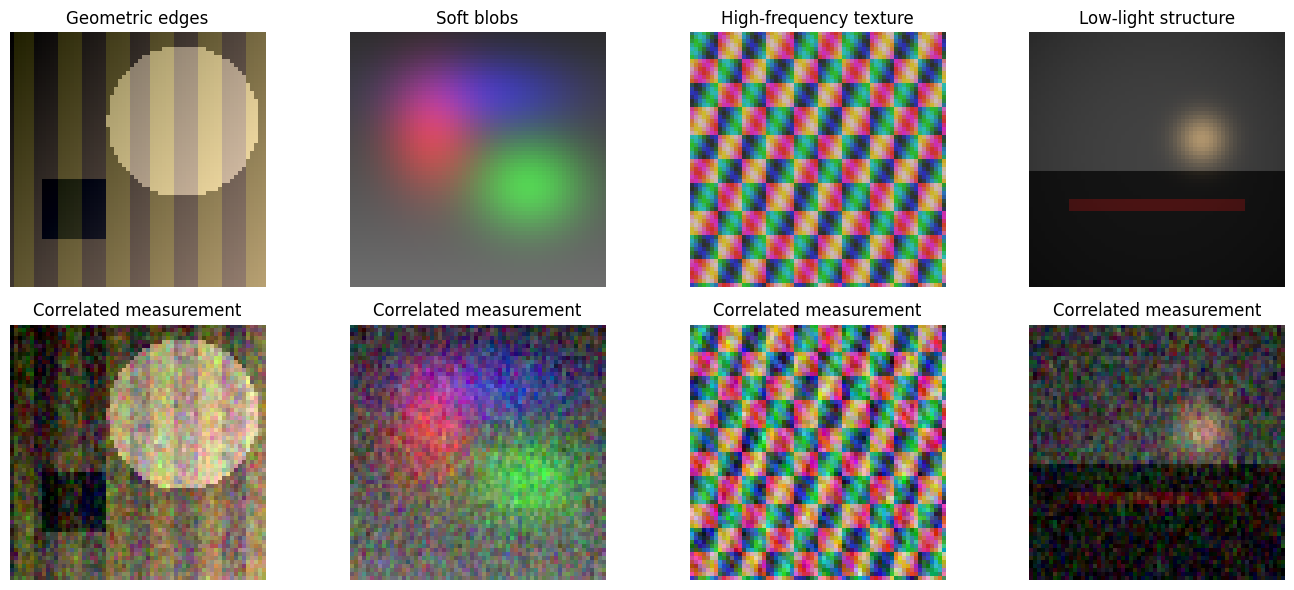

In [50]:
def image_to_tensor01(image: FloatArray) -> torch.Tensor:
    return torch.tensor(image, dtype=torch.float32, device=DEVICE).permute(2, 0, 1).unsqueeze(0)


def tensor01_to_image(tensor: torch.Tensor) -> FloatArray:
    array = tensor.detach().clamp(0, 1).squeeze(0).permute(1, 2, 0).cpu().numpy()
    return np.clip(array, 0.0, 1.0).astype(np.float32)


def extract_patch_matrix(image01: torch.Tensor, patch_size: int) -> torch.Tensor:
    patches = torch_functional.unfold(image01, kernel_size=patch_size, stride=patch_size)
    batch, _, count = patches.shape
    channels = image01.shape[1]
    return patches.reshape(batch, channels, patch_size * patch_size, count)



def fold_patch_matrix(
    patches: torch.Tensor,
    height: int,
    width: int,
    patch_size: int,
) -> torch.Tensor:
    batch, channels, pixels, count = patches.shape
    merged = patches.reshape(batch, channels * pixels, count)
    return torch_functional.fold(
        merged,
        output_size=(height, width),
        kernel_size=patch_size,
        stride=patch_size,
    )


def add_correlated_noise(
    clean01: torch.Tensor,
    model: CardNoiseModel,
    sigma_y: float,
    seed: int = 7,
) -> torch.Tensor:
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    patches = extract_patch_matrix(clean01, model.patch_size)
    white_noise = torch.randn(patches.shape, generator=generator, device=DEVICE)
    correlated = torch.einsum("ij,bcjn->bcin", model.coloring, white_noise)
    noisy_patches = patches + sigma_y * correlated
    return fold_patch_matrix(
        noisy_patches,
        clean01.shape[-2],
        clean01.shape[-1],
        model.patch_size,
    ).clamp(0, 1)


SIGMA_Y: Final = 0.08
measurement_previews = []
for index, test_image in enumerate(TEST_IMAGES):
    clean_tensor = image_to_tensor01(test_image.clean)
    measurement = add_correlated_noise(clean_tensor, NOISE_MODEL, SIGMA_Y, seed=7 + index)
    measurement_previews.append(tensor01_to_image(measurement))

fig, axes = plt.subplots(2, len(TEST_IMAGES), figsize=(14, 6))
for index, test_image in enumerate(TEST_IMAGES):
    axes[0, index].imshow(test_image.clean)
    axes[0, index].set_title(test_image.name)
    axes[0, index].axis("off")
    axes[1, index].imshow(measurement_previews[index])
    axes[1, index].set_title("Correlated measurement")
    axes[1, index].axis("off")
plt.tight_layout()
plt.show()


## whitened DDRM-Style Measurement Update

The paper's CARD update replaces DDRM's `(s_i, y_bar_i)` terms with the whitened terms `(s_tilde_i, y_tilde_bar_i)`, where `H_tilde = U_tilde S_tilde V_tilde^T`.

This cell implements that denoising specialization patchwise:

1. predict `x_theta,t` from the frozen diffusion model;
2. project prediction and measurement into the `V_tilde` spectral coordinates;
3. compute the whitened measurement coordinate `y_tilde_bar = S_tilde^-1 U_tilde^T W y`;
4. blend each coordinate according to its effective measurement noise `delta_i = sigma_y / s_tilde_i`;
5. fold corrected patches back into an image and continue sampling.

This removes the previous `cond_fn` gradient guidance path. The remaining approximation is that OpenAI guided-diffusion exposes a DDPM sampler.
        


In [51]:
def to_model_range(image01: torch.Tensor) -> torch.Tensor:
    return image01 * 2.0 - 1.0


def from_model_range(image11: torch.Tensor) -> torch.Tensor:
    return ((image11 + 1.0) / 2.0).clamp(0, 1)


def diffusion_sigma(diffusion: object, timestep: int, device: torch.device) -> torch.Tensor:
    alpha_bar = torch.tensor(float(diffusion.alphas_cumprod[timestep]), device=device)
    return torch.sqrt((1.0 - alpha_bar).clamp_min(0.0) / alpha_bar.clamp_min(1e-8))


def whitened_measurement_coordinates(
    observed01: torch.Tensor,
    model: CardNoiseModel,
) -> torch.Tensor:
    patches = extract_patch_matrix(observed01, model.patch_size)
    y_tilde = torch.einsum("ij,bcjn->bcin", model.whitening, patches)
    projected = torch.einsum("ij,bcjn->bcin", model.svd_u.T, y_tilde)
    return projected / model.singular_values.reshape(1, 1, -1, 1).clamp_min(1e-8)


@dataclass(frozen=True)
class CardUpdateState:
    pred_xstart11: torch.Tensor
    observed01: torch.Tensor
    sigma_t: torch.Tensor


def card_whitened_ddrm_update(
    state: CardUpdateState,
    model: CardNoiseModel,
    sigma_y: float,
    eta_b: float,
) -> torch.Tensor:
    pred01 = from_model_range(state.pred_xstart11)
    pred_patches = extract_patch_matrix(pred01, model.patch_size)
    pred_bar = torch.einsum("ij,bcjn->bcin", model.svd_vh, pred_patches)
    measurement_bar = whitened_measurement_coordinates(state.observed01, model)

    delta = sigma_y / model.singular_values.clamp_min(1e-8)
    sigma_t_value = state.sigma_t.reshape(1, 1, 1, 1)
    delta_value = delta.reshape(1, 1, -1, 1)

    high_noise_weight = torch.full_like(delta_value, eta_b)
    low_noise_weight = eta_b * (sigma_t_value / delta_value.clamp_min(1e-8)).clamp(0.0, 1.0)
    measurement_weight = torch.where(
        sigma_t_value >= delta_value,
        high_noise_weight,
        low_noise_weight,
    )

    corrected_bar = (1.0 - measurement_weight) * pred_bar + measurement_weight * measurement_bar
    corrected_patches = torch.einsum("ij,bcjn->bcin", model.svd_vh.T, corrected_bar)
    corrected01 = fold_patch_matrix(
        corrected_patches,
        state.observed01.shape[-2],
        state.observed01.shape[-1],
        model.patch_size,
    ).clamp(0, 1)
    return to_model_range(corrected01)


## CARD Sampling Loop Across Test Images

In [52]:
CLASS_LABEL: Final = 207
ETA_B: Final = 0.3


@dataclass(frozen=True)
class RestorationResult:
    name: str
    clean: FloatArray
    noisy: FloatArray
    baseline: FloatArray
    restored: FloatArray



def run_card_whitened_ddrm_denoising(
    observed01: torch.Tensor,
    model: CardNoiseModel,
    sigma_y: float,
) -> torch.Tensor:
    model_kwargs = {"y": torch.tensor([CLASS_LABEL], dtype=torch.long, device=DEVICE)}
    sample = torch.randn_like(to_model_range(observed01))

    for index in reversed(range(DIFFUSION.num_timesteps)):
        timestep = torch.full((sample.shape[0],), index, dtype=torch.long, device=DEVICE)
        with torch.no_grad():
            prediction = DIFFUSION.p_mean_variance(
                DIFFUSION_MODEL,
                sample,
                timestep,
                clip_denoised=True,
                model_kwargs=model_kwargs,
            )
            update_state = CardUpdateState(
                pred_xstart11=prediction["pred_xstart"],
                observed01=observed01,
                sigma_t=diffusion_sigma(DIFFUSION, index, DEVICE),
            )
            corrected_xstart = card_whitened_ddrm_update(
                update_state,
                model,
                sigma_y,
                ETA_B,
            )
            if index > 0:
                previous = torch.full(
                    (sample.shape[0],),
                    index - 1,
                    dtype=torch.long,
                    device=DEVICE,
                )
                sample = DIFFUSION.q_sample(
                    corrected_xstart,
                    previous,
                    noise=torch.randn_like(sample),
                )
            else:
                sample = corrected_xstart
    return from_model_range(sample)


def gaussian_kernel1d(sigma: float = 0.9) -> FloatArray:
      radius = max(1, round(3 * sigma))
      offsets = np.arange(-radius, radius + 1, dtype=np.float32)
      kernel = np.exp(-(offsets**2) / (2 * sigma**2))
      return (kernel / np.sum(kernel)).astype(np.float32)


def gaussian_denoise_rgb(image: FloatArray, sigma: float = 0.9) -> FloatArray:
    kernel = gaussian_kernel1d(sigma)
    radius = len(kernel) // 2
    output = np.empty_like(image)
    for channel in range(image.shape[-1]):
        channel_image = image[..., channel]
        rows = np.empty_like(channel_image)
        for row_index, row in enumerate(channel_image):
            rows[row_index, :] = np.convolve(
                np.pad(row, radius, mode="reflect"),
                kernel,
                mode="valid",
            )
        cols = np.empty_like(channel_image)
        for col_index in range(channel_image.shape[1]):
            cols[:, col_index] = np.convolve(
                np.pad(rows[:, col_index], radius, mode="reflect"),
                kernel,
                mode="valid",
            )
        output[..., channel] = cols
    return np.clip(output, 0.0, 1.0).astype(np.float32)



def restore_test_image(test_image: TestImage, seed: int) -> RestorationResult:
    clean_tensor = image_to_tensor01(test_image.clean)
    noisy_tensor = add_correlated_noise(clean_tensor, NOISE_MODEL, SIGMA_Y, seed=seed)
    noisy_np = tensor01_to_image(noisy_tensor)
    baseline_np = gaussian_denoise_rgb(noisy_np)
    restored_tensor = run_card_whitened_ddrm_denoising(noisy_tensor, NOISE_MODEL, SIGMA_Y)
    return RestorationResult(
        name=test_image.name,
        clean=test_image.clean,
        noisy=noisy_np,
        baseline=baseline_np,
        restored=tensor01_to_image(restored_tensor),
    )



RESULTS = [
    restore_test_image(test_image, seed=7 + index)
    for index, test_image in enumerate(TEST_IMAGES)
]


## Metrics, Comparison Grids, and Summary Charts


Geometric edges: PSNR 22.10 -> 29.37 (gain 7.27), SSIM 0.940 -> 0.988 (gain 0.048)
Soft blobs: PSNR 21.96 -> 29.36 (gain 7.40), SSIM 0.833 -> 0.964 (gain 0.131)
High-frequency texture: PSNR 21.94 -> 27.09 (gain 5.15), SSIM 0.949 -> 0.984 (gain 0.035)
Low-light structure: PSNR 22.49 -> 30.63 (gain 8.14), SSIM 0.779 -> 0.958 (gain 0.180)


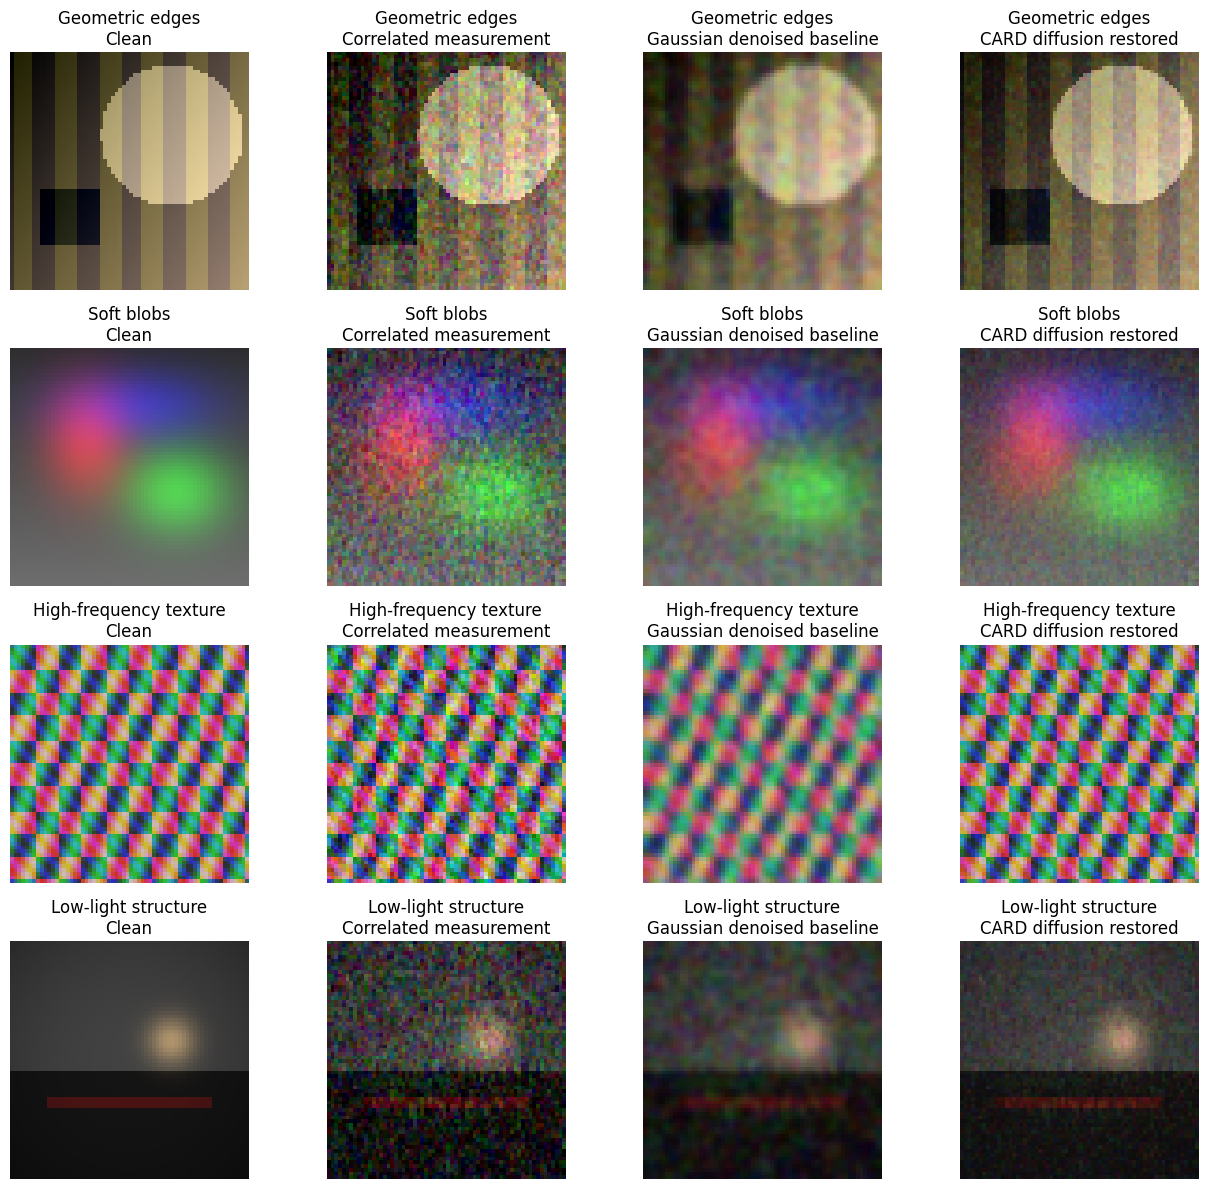

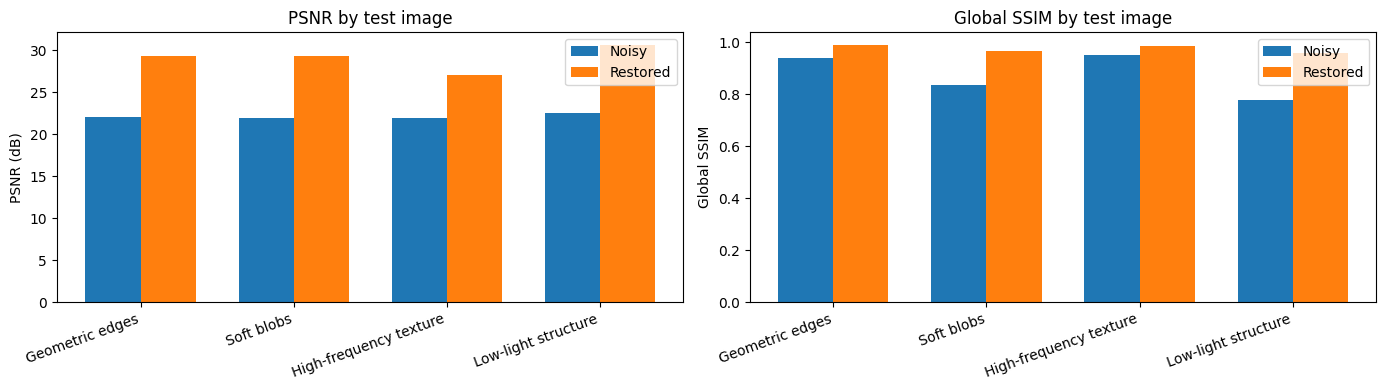

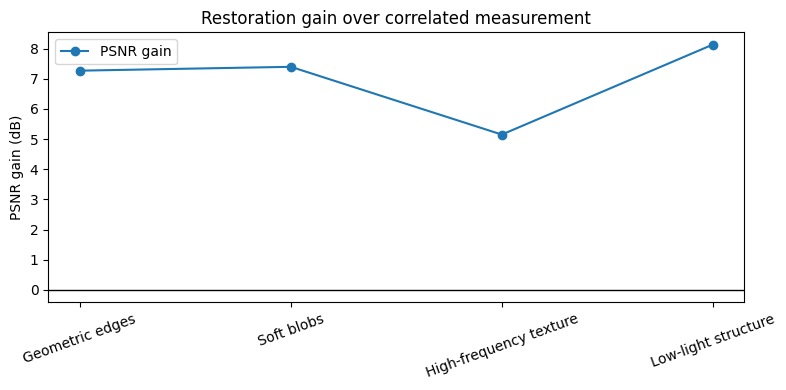

In [53]:
def psnr(reference: FloatArray, candidate: FloatArray) -> float:
    mse = float(np.mean((reference - candidate) ** 2))
    return 99.0 if mse <= 0.0 else 10.0 * math.log10(1.0 / mse)


def global_ssim(reference: FloatArray, candidate: FloatArray) -> float:
    c1 = 0.01**2
    c2 = 0.03**2
    ref_mean = float(np.mean(reference))
    cand_mean = float(np.mean(candidate))
    ref_var = float(np.var(reference))
    cand_var = float(np.var(candidate))
    covariance = float(np.mean((reference - ref_mean) * (candidate - cand_mean)))
    numerator = (2 * ref_mean * cand_mean + c1) * (2 * covariance + c2)
    denominator = (ref_mean**2 + cand_mean**2 + c1) * (ref_var + cand_var + c2)
    return numerator / denominator


def metric_rows(results: list[RestorationResult]) -> list[dict[str, float | str]]:
    rows: list[dict[str, float | str]] = []
    for result in results:
        noisy_psnr = psnr(result.clean, result.noisy)
        restored_psnr = psnr(result.clean, result.restored)
        noisy_ssim = global_ssim(result.clean, result.noisy)
        restored_ssim = global_ssim(result.clean, result.restored)
        rows.append(
            {
                "image": result.name,
                "noisy_psnr": noisy_psnr,
                "restored_psnr": restored_psnr,
                "psnr_gain": restored_psnr - noisy_psnr,
                "noisy_ssim": noisy_ssim,
                "restored_ssim": restored_ssim,
                "ssim_gain": restored_ssim - noisy_ssim,
            }
        )
    return rows


METRICS = metric_rows(RESULTS)
for row in METRICS:
    print(
        f"{row['image']}: "
        f"PSNR {row['noisy_psnr']:.2f} -> {row['restored_psnr']:.2f} "
        f"(gain {row['psnr_gain']:.2f}), "
        f"SSIM {row['noisy_ssim']:.3f} -> {row['restored_ssim']:.3f} "
        f"(gain {row['ssim_gain']:.3f})"
    )

fig, axes = plt.subplots(len(RESULTS), 4, figsize=(13, 3 * len(RESULTS)))

for row_index, result in enumerate(RESULTS):
    panels = [
        ("Clean", result.clean),
        ("Correlated measurement", result.noisy),
        ("Gaussian denoised baseline", result.baseline),
        ("CARD diffusion restored", result.restored),
    ]

    for col_index, (title, image) in enumerate(panels):
        axes[row_index, col_index].imshow(image)
        axes[row_index, col_index].set_title(f"{result.name}\n{title}")
        axes[row_index, col_index].axis("off")
plt.tight_layout()
plt.show()

names = [str(row["image"]) for row in METRICS]
x_positions = np.arange(len(names))
bar_width = 0.36

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(
    x_positions - bar_width / 2,
    [float(row["noisy_psnr"]) for row in METRICS],
    bar_width,
    label="Noisy",
)
axes[0].bar(
    x_positions + bar_width / 2,
    [float(row["restored_psnr"]) for row in METRICS],
    bar_width,
    label="Restored",
)
axes[0].set_title("PSNR by test image")
axes[0].set_ylabel("PSNR (dB)")
axes[0].set_xticks(x_positions, names, rotation=20, ha="right")
axes[0].legend()

axes[1].bar(
    x_positions - bar_width / 2,
    [float(row["noisy_ssim"]) for row in METRICS],
    bar_width,
    label="Noisy",
)
axes[1].bar(
    x_positions + bar_width / 2,
    [float(row["restored_ssim"]) for row in METRICS],
    bar_width,
    label="Restored",
)
axes[1].set_title("Global SSIM by test image")
axes[1].set_ylabel("Global SSIM")
axes[1].set_xticks(x_positions, names, rotation=20, ha="right")
axes[1].legend()
plt.tight_layout()
plt.show()

fig, axis = plt.subplots(figsize=(8, 4))
axis.axhline(0.0, color="black", linewidth=1)
axis.plot(names, [float(row["psnr_gain"]) for row in METRICS], marker="o", label="PSNR gain")
axis.set_title("Restoration gain over correlated measurement")
axis.set_ylabel("PSNR gain (dB)")
axis.tick_params(axis="x", rotation=20)
axis.legend()
plt.tight_layout()
plt.show()


## Save Outputs


In [54]:
OUTPUT_DIR = Path("/content/card_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for index, result in enumerate(RESULTS, start=1):
    slug = result.name.lower().replace("-", "").replace(" ", "_")
    clean_path = OUTPUT_DIR / f"{index}_{slug}_clean.png"
    noisy_path = OUTPUT_DIR / f"{index}_{slug}_noisy.png"
    Image.fromarray((result.clean * 255).astype(np.uint8)).save(clean_path)
    Image.fromarray((result.noisy * 255).astype(np.uint8)).save(noisy_path)
    Image.fromarray((result.restored * 255).astype(np.uint8)).save(
        OUTPUT_DIR / f"{index}_{slug}_restored.png"
    )

print("Saved result images under", OUTPUT_DIR)


Saved result images under /content/card_outputs
